# Retail Sales Exploratory Data Analysis (EDA)



## Tools & Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [25]:
df = pd.read_csv(r"C:\Users\dell\Downloads\\retail_sales_50k_messy.csv")
df.head()

,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel
0,100000,06/25/2023,Bengaluru,South,Beauty,Face Wash,1.0,11521.49,0.0,11521.49,11521.49,NaN,New,Online
1,100001,2024-05-17,Kolkata,East,Beauty,Face Wash,2.0,22032.78,15.0,18727.86,37455.72,Credit Card,NaN,Online
2,100002,NaN,Mumbai,West,Fashion,T-Shirt,-1.0,48903.88,10.0,44013.49,-44013.49,NaN,Returning,Online
3,100003,2024-02-03,MUMBAI,NaN,Fashion,Jacket,1.0,13340.77,0.0,13340.77,13340.77,Cash on Delivery,NaN,In-Store
4,100004,12/12/2023,Bangalore,NaN,Beauty,Moisturizer,3.0,3788.15,5.0,3598.74,10796.22,NaN,Returning,In-Store


# Data  Cleaning

In [26]:
#How many rows and columns are present in the dataset?
df.shape

(50000, 14)

In [27]:
#Percentage of missing values in each column
(df.isnull().mean() * 100).round(2)



order_id             0.00
order_date          24.97
city                 9.00
region              36.61
category             0.00
product              0.00
quantity            16.34
unit_price           1.03
discount_percent    16.85
final_unit_price    30.52
revenue             30.52
payment_method      19.77
customer_type       33.23
sales_channel        0.00
dtype: float64

In [28]:
#Which columns have the highest data quality issues?
df.isnull().sum().sort_values(ascending=False)


region              18306
customer_type       16617
final_unit_price    15258
revenue             15258
order_date          12487
payment_method       9883
discount_percent     8426
quantity             8171
city                 4499
unit_price            516
product                 0
category                0
order_id                0
sales_channel           0
dtype: int64

In [29]:
#How many duplicate order IDs are present?
duplicate_orders = df.duplicated(subset='order_id').sum()
print("Duplicate order IDs:", duplicate_orders)

df = df.drop_duplicates(subset='order_id')

print("Shape after removing duplicates:", df.shape)

df.head()


Duplicate order IDs: 110
Shape after removing duplicates: (49890, 14)


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel
0,100000,06/25/2023,Bengaluru,South,Beauty,Face Wash,1.0,11521.49,0.0,11521.49,11521.49,NaN,New,Online
1,100001,2024-05-17,Kolkata,East,Beauty,Face Wash,2.0,22032.78,15.0,18727.86,37455.72,Credit Card,NaN,Online
2,100002,NaN,Mumbai,West,Fashion,T-Shirt,-1.0,48903.88,10.0,44013.49,-44013.49,NaN,Returning,Online
3,100003,2024-02-03,MUMBAI,NaN,Fashion,Jacket,1.0,13340.77,0.0,13340.77,13340.77,Cash on Delivery,NaN,In-Store
4,100004,12/12/2023,Bangalore,NaN,Beauty,Moisturizer,3.0,3788.15,5.0,3598.74,10796.22,NaN,Returning,In-Store


In [10]:
#How many invalid or negative quantities exist?
df[df["quantity"] <= 0].shape[0]

8433

In [11]:
#present City#
df["city"] = df["city"].str.lower().str.strip()
df


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel
0,100000,06/25/2023,bengaluru,South,Beauty,Face Wash,1.0,11521.49,0.0,11521.49,11521.49,NaN,New,Online
1,100001,2024-05-17,kolkata,East,Beauty,Face Wash,2.0,22032.78,15.0,18727.86,37455.72,Credit Card,NaN,Online
2,100002,NaN,mumbai,West,Fashion,T-Shirt,-1.0,48903.88,10.0,44013.49,-44013.49,NaN,Returning,Online
3,100003,2024-02-03,mumbai,NaN,Fashion,Jacket,1.0,13340.77,0.0,13340.77,13340.77,Cash on Delivery,NaN,In-Store
4,100004,12/12/2023,bangalore,NaN,Beauty,Moisturizer,3.0,3788.15,5.0,3598.74,10796.22,NaN,Returning,In-Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,149994,NaN,kolkata,East,Fashion,Jacket,-1.0,45151.98,10.0,40636.78,-40636.78,Credit Card,Returning,Online
49995,149995,06/15/2024,mumbai,West,Home & Kitchen,Cookware Set,3.0,46706.12,0.0,46706.12,140118.36,Debit Card,New,Online
49996,149996,09/10/2023,kolkata,East,Home & Kitchen,Vacuum Cleaner,-1.0,10661.07,0.0,10661.07,-10661.07,UPI,Returning,In-Store
49998,149998,01-01-2024,NaN,NaN,Electronics,Smartphone,NaN,32082.46,NaN,NaN,NaN,Credit Card,Returning,Online


In [30]:
#How many records have missing or incorrect dates?
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_date"].isnull().sum()



np.int64(37349)

In [31]:
#List inconsistent city name variations
df["city"].unique()

array(['Bengaluru', 'Kolkata', 'Mumbai', 'MUMBAI', 'Bangalore', 'delhi ',
       'Delhi', nan, 'Chennai', 'Pune', 'Hyderabad'], dtype=object)

In [32]:
# Handle missing price and discount
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())
df['discount_percent'] = df['discount_percent'].fillna(0)
df.head()


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel
0,100000,2023-06-25,Bengaluru,South,Beauty,Face Wash,1.0,11521.49,0.0,11521.49,11521.49,NaN,New,Online
1,100001,NaT,Kolkata,East,Beauty,Face Wash,2.0,22032.78,15.0,18727.86,37455.72,Credit Card,NaN,Online
2,100002,NaT,Mumbai,West,Fashion,T-Shirt,-1.0,48903.88,10.0,44013.49,-44013.49,NaN,Returning,Online
3,100003,NaT,MUMBAI,NaN,Fashion,Jacket,1.0,13340.77,0.0,13340.77,13340.77,Cash on Delivery,NaN,In-Store
4,100004,2023-12-12,Bangalore,NaN,Beauty,Moisturizer,3.0,3788.15,5.0,3598.74,10796.22,NaN,Returning,In-Store


In [33]:
# Recalculate revenue
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount_percent']/100)
df.head()


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel
0,100000,2023-06-25,Bengaluru,South,Beauty,Face Wash,1.0,11521.49,0.0,11521.49,11521.4900,NaN,New,Online
1,100001,NaT,Kolkata,East,Beauty,Face Wash,2.0,22032.78,15.0,18727.86,37455.7260,Credit Card,NaN,Online
2,100002,NaT,Mumbai,West,Fashion,T-Shirt,-1.0,48903.88,10.0,44013.49,-44013.4920,NaN,Returning,Online
3,100003,NaT,MUMBAI,NaN,Fashion,Jacket,1.0,13340.77,0.0,13340.77,13340.7700,Cash on Delivery,NaN,In-Store
4,100004,2023-12-12,Bangalore,NaN,Beauty,Moisturizer,3.0,3788.15,5.0,3598.74,10796.2275,NaN,Returning,In-Store


In [34]:
#Which rows contain extreme price outliers?

before = df.shape[0]

Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['unit_price'] >= Q1 - 1.5*IQR) &
        (df['unit_price'] <= Q3 + 1.5*IQR)]

after = df.shape[0]

print("Rows removed:", before - after)
print("Remaining rows:", after)





Rows removed: 489
Remaining rows: 49401


In [35]:
df["city"].unique()


array(['Bengaluru', 'Kolkata', 'Mumbai', 'MUMBAI', 'Bangalore', 'delhi ',
       'Delhi', nan, 'Chennai', 'Pune', 'Hyderabad'], dtype=object)

In [38]:
#How many rows have missing revenue values?
print("missing revenue value is:", df["revenue"].isnull().sum())

missing revenue value is: 8076


In [37]:
#After cleaning, how many valid transactions remain?
df.shape

(49401, 14)

## Data Quality Issues Identified
- Missing values
- Duplicate order IDs
- Inconsistent city names
- Invalid quantities
- Incorrect revenue values

# Descriptive EDA

<Axes: ylabel='proportion'>

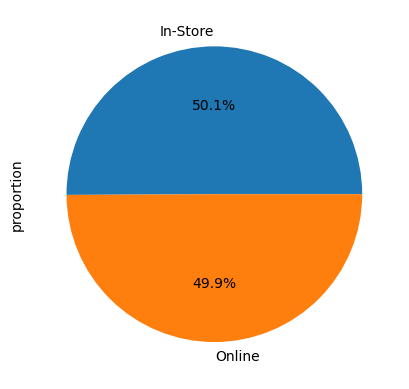

In [42]:
#Total revenue generated
df["revenue"].sum()

#Average order value
df["revenue"].mean()

#Which city generates the highest revenue?
df.groupby("city")["revenue"].sum().idxmax()

#Which region performs best overall?
df.groupby("region")["revenue"].sum().idxmax()

#Top 10 selling products by revenue
df.groupby("product")["revenue"].sum().sort_values(ascending=False).head(10)

# Which product category contributes most to revenue?
df.groupby("category")["revenue"].sum().idxmax()

# Least performing category
df.groupby("category")["revenue"].sum().idxmin()

#median quantity per order
df["quantity"].median()

# Most frequently used payment method
df["payment_method"].value_counts().idxmax()

# Online vs in-store sales percentage
df["sales_channel"].value_counts(normalize=True) * 100

df["sales_channel"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%")

# Time Based Analysis

In [54]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [55]:
df["month"] = df["order_date"].dt.month

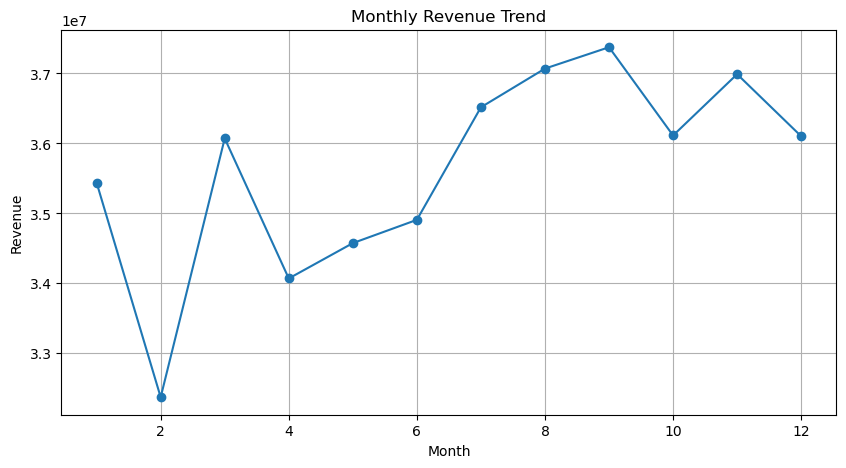

In [53]:
import matplotlib.pyplot as plt

monthly_revenue = df.groupby("month")["revenue"].sum()

monthly_revenue.plot(figsize=(10,5), marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

In [56]:
#Which month has the highest sales?
monthly_revenue.idxmax()


np.float64(9.0)

In [57]:
#Which month has the lowest sales?
monthly_revenue.idxmin()



np.float64(2.0)

In [58]:
#Is there any seasonality pattern in sales?

monthly_revenue



month
1.0     3.543796e+07
2.0     3.237292e+07
3.0     3.607144e+07
4.0     3.407007e+07
5.0     3.457516e+07
6.0     3.490786e+07
7.0     3.651659e+07
8.0     3.706933e+07
9.0     3.737467e+07
10.0    3.611327e+07
11.0    3.698945e+07
12.0    3.610258e+07
Name: revenue, dtype: float64

<Axes: title={'center': 'Average Order Value by Month'}, xlabel='month'>

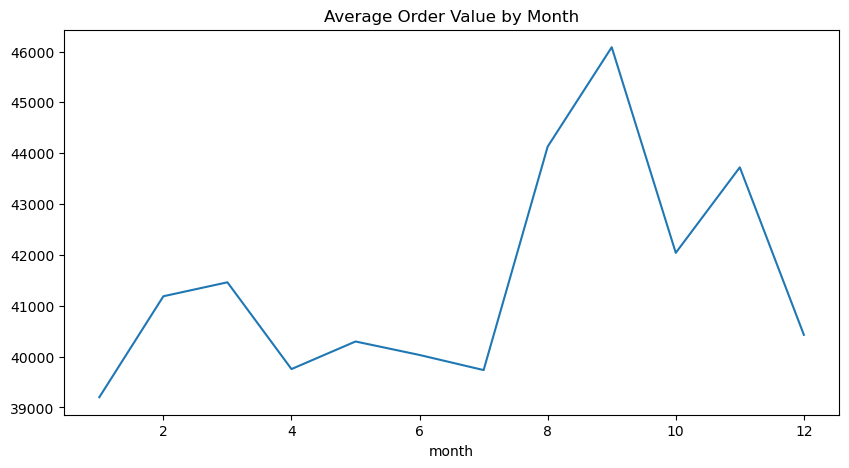

In [59]:
#Average order value month-to-month

monthly_aov = df.groupby("month")["revenue"].mean()

monthly_aov.plot(figsize=(10,5), title="Average Order Value by Month")




In [61]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [62]:
df["weekday"] = df["order_date"].dt.day_name()

In [63]:
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

In [65]:
#Are weekend sales higher than weekday sales?
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])
df.groupby("is_weekend")["revenue"].sum()
df.groupby("is_weekend")["revenue"].mean()




is_weekend
False    41099.183832
True     42135.042430
Name: revenue, dtype: float64

In [66]:
#Which quarter contributes most revenue?

df["quarter"] = df["order_date"].dt.quarter
df.groupby("quarter")["revenue"].sum().sort_values(ascending=False)

quarter
3.0    1.109606e+08
4.0    1.092053e+08
1.0    1.038823e+08
2.0    1.035531e+08
Name: revenue, dtype: float64

# Customer Behavior

In [67]:
#Do returning customers spend more than new customers?
df.groupby("customer_type")["revenue"].mean()


customer_type
New          41575.736740
Returning    41380.314546
Name: revenue, dtype: float64

In [68]:
#Which customer type generates more revenue share?
df.groupby("customer_type")["revenue"].sum()



customer_type
New          5.774038e+08
Returning    5.674896e+08
Name: revenue, dtype: float64

In [69]:
#Average quantity per customer type
df.groupby("customer_type")["quantity"].mean()



customer_type
New          1.798027
Returning    1.797433
Name: quantity, dtype: float64

In [70]:
#Which city has the highest returning-customer ratio?
returning_ratio = (
    df[df["customer_type"] == "Returning"]
    .groupby("city")
    .size()
    /
    df.groupby("city").size()
)

returning_ratio.sort_values(ascending=False).head()


city
MUMBAI       0.346297
Bangalore    0.338998
delhi        0.337252
Kolkata      0.336501
Delhi        0.333705
dtype: float64

In [71]:
#Are discounts more common for new customers?
df.groupby("customer_type")["discount_percent"].mean()



customer_type
New          8.266168
Returning    8.296154
Name: discount_percent, dtype: float64

# Pricing and discount insight

In [72]:
#average discount percentage overall

df["discount_percent"].mean() * 100



np.float64(828.5662233558024)

In [73]:
#Which category gives the highest discounts?

df.groupby("category")["discount_percent"].mean().sort_values(ascending=False)



category
Beauty            8.323417
Electronics       8.306660
Fashion           8.264383
Home & Kitchen    8.248547
Name: discount_percent, dtype: float64

In [74]:
#Do higher discounts increase revenue?
df[["discount_percent", "revenue"]].corr()



,discount_percent,revenue
discount_percent,1.000000,-0.066116
revenue,-0.066116,1.000000


In [75]:
#Correlation between discount, price, and quantity

df[["discount_percent", "unit_price", "quantity"]].corr()


,discount_percent,unit_price,quantity
discount_percent,1.000000,-0.000811,-0.003548
unit_price,-0.000811,1.000000,0.001203
quantity,-0.003548,0.001203,1.000000


In [76]:
#Identify loss-making or suspicious transactions
df.sort_values("unit_price", ascending=False).head()


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel,month,weekday,is_weekend,quarter
32511,132511,NaT,Bengaluru,South,Fashion,T-Shirt,3.0,49999.51,0.0,49999.51,149998.53,Cash on Delivery,NaN,In-Store,NaN,NaN,False,NaN
21497,121497,2023-05-20,Kolkata,East,Fashion,Jeans,1.0,49999.25,0.0,NaN,49999.25,Cash on Delivery,New,In-Store,5.0,Saturday,True,2.0
43614,143614,NaT,Hyderabad,South,Beauty,Perfume,3.0,49999.17,0.0,49999.17,149997.51,UPI,NaN,In-Store,NaN,NaN,False,NaN
21181,121181,2023-06-20,Mumbai,West,Home & Kitchen,Cookware Set,NaN,49998.57,0.0,NaN,NaN,Cash on Delivery,Returning,Online,6.0,Tuesday,False,2.0
40395,140395,NaT,Bangalore,NaN,Beauty,Perfume,4.0,49997.53,0.0,49997.53,199990.12,UPI,Returning,In-Store,NaN,NaN,False,NaN


# Geographic Insights

In [77]:
#Which top 5 cities contribute most revenue?
df.groupby("city")["revenue"].sum().sort_values(ascending=False).head(5)


city
delhi      1.597646e+08
Kolkata    1.587611e+08
Pune       1.585157e+08
Chennai    1.564588e+08
MUMBAI     1.558521e+08
Name: revenue, dtype: float64

In [78]:
#Which region has lowest performance?

df.groupby("region")["revenue"].sum().sort_values().head(1)




region
North    1.542549e+08
Name: revenue, dtype: float64

In [79]:
#Category preference differences across regions
pivot_table = pd.pivot_table(
    df,
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum"
)

pivot_table



category,Beauty,Electronics,Fashion,Home & Kitchen
region,,,,
East,4.322401e+07,3.639921e+07,3.739064e+07,4.174729e+07
North,3.668762e+07,3.770633e+07,3.797147e+07,4.188946e+07
South,1.139535e+08,1.144830e+08,1.153559e+08,1.117010e+08
West,7.452514e+07,7.766765e+07,7.991765e+07,7.837598e+07


In [80]:
#Which city buys most electronics?

df[df["category"] == "Electronics"] \
.groupby("city")["revenue"] \
.sum() \
.sort_values(ascending=False) \
.head(1)


city
delhi     4.356214e+07
Name: revenue, dtype: float64

In [81]:
#Which city prefers fashion products?
# Which city prefers fashion products?
df[df["category"] == "Fashion"] \
.groupby("city")["revenue"] \
.sum() \
.sort_values(ascending=False) \
.head(1)


city
Pune    4.343545e+07
Name: revenue, dtype: float64

# Outliers & Anomaly Detection

In [82]:
#Detect price outliers using IQR
Q1 = df["unit_price"].quantile(0.25)
Q3 = df["unit_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df["unit_price"] < lower_bound) |
    (df["unit_price"] > upper_bound)
]

print("Price outliers:", price_outliers.shape[0])


Price outliers: 0


In [83]:
#Detect abnormally high revenue orders
Q1 = df["revenue"].quantile(0.25)
Q3 = df["revenue"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

high_revenue_orders = df[df["revenue"] > upper_bound]

print("High revenue orders:", high_revenue_orders.shape[0])
high_revenue_orders.head()

High revenue orders: 450


,order_id,order_date,city,region,category,product,quantity,unit_price,discount_percent,final_unit_price,revenue,payment_method,customer_type,sales_channel,month,weekday,is_weekend,quarter
12,100012,NaT,Kolkata,East,Beauty,Face Wash,4.0,47516.45,0.0,47516.45,190065.800,Cash on Delivery,New,Online,NaN,NaN,False,NaN
51,100051,NaT,Pune,West,Fashion,Sneakers,4.0,46967.75,5.0,44619.36,178477.450,Cash on Delivery,Returning,In-Store,NaN,NaN,False,NaN
208,100208,2023-12-15,delhi,NaN,Fashion,Jeans,4.0,48249.35,0.0,NaN,192997.400,NaN,NaN,Online,12.0,Friday,False,4.0
295,100295,NaT,Mumbai,West,Fashion,Jacket,4.0,46681.71,5.0,44347.62,177390.498,Cash on Delivery,Returning,Online,NaN,NaN,False,NaN
358,100358,NaT,NaN,NaN,Beauty,Perfume,4.0,47610.41,0.0,NaN,190441.640,Credit Card,Returning,Online,NaN,NaN,False,NaN


In [84]:
#Are outliers data errors or real premium sales?


high_revenue_orders[[
    "product",
    "unit_price",
    "quantity",
    "discount_percent",
    "revenue"
]]

,product,unit_price,quantity,discount_percent,revenue
12,Face Wash,47516.45,4.0,0.0,190065.800
51,Sneakers,46967.75,4.0,5.0,178477.450
208,Jeans,48249.35,4.0,0.0,192997.400
295,Jacket,46681.71,4.0,5.0,177390.498
358,Perfume,47610.41,4.0,0.0,190441.640
...,...,...,...,...,...
49560,Moisturizer,47887.63,4.0,5.0,181972.994
49758,Cookware Set,47268.94,4.0,5.0,179621.972
49880,Water Purifier,44514.67,4.0,0.0,178058.680
49937,Jeans,48892.44,4.0,0.0,195569.760


In [85]:
#Impact of removing outliers on average revenue
avg_before = df["revenue"].mean()

df_no_outliers = df[df["revenue"] <= upper_bound]

avg_after = df_no_outliers["revenue"].mean()

print("Average revenue before:", avg_before)
print("Average revenue after:", avg_after)

Average revenue before: 41174.382278294004
Average revenue after: 39569.01252835474


# Visualization Task

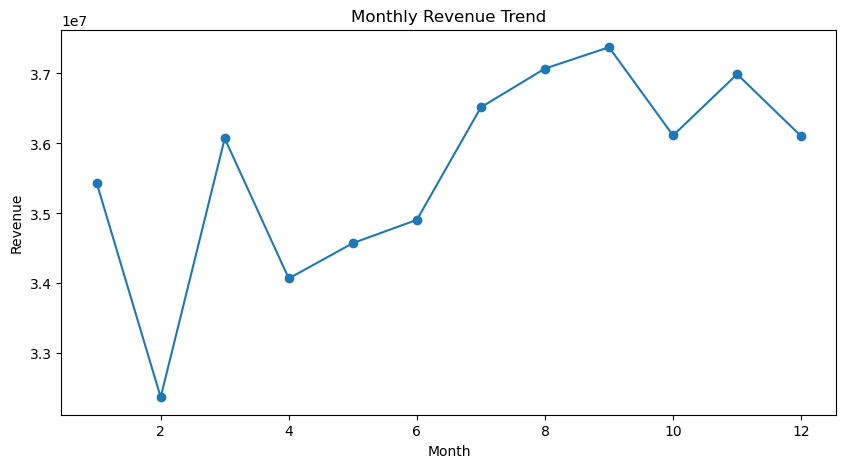

In [86]:
#Monthly revenue line chart
monthly_revenue = df.groupby("month")["revenue"].sum()

monthly_revenue.plot(
    figsize=(10,5),
    marker="o",
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


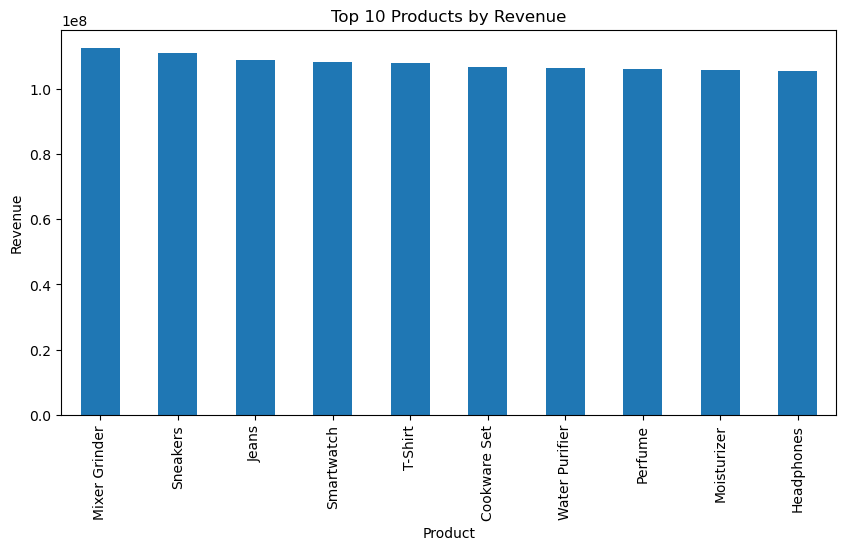

In [87]:
#Top products bar chart
top_products = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Products by Revenue"
)

plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

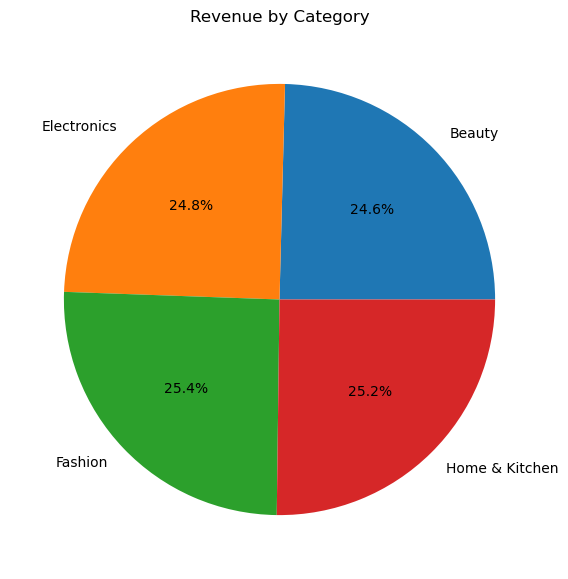

In [88]:
#Category revenue pie chart
category_revenue = df.groupby("category")["revenue"].sum()

category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7),
    title="Revenue by Category"
)

plt.ylabel("")
plt.show()

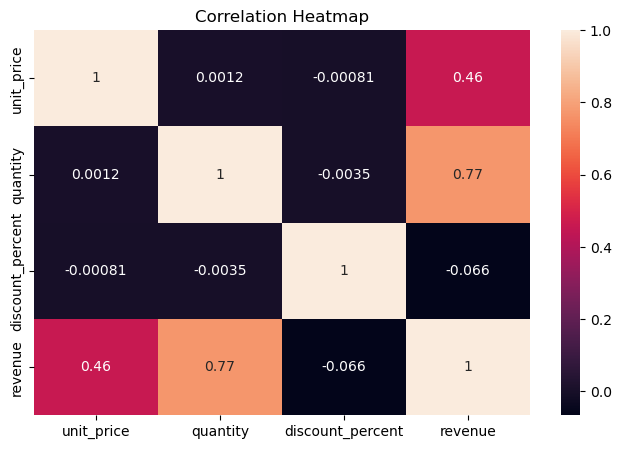

In [89]:
#Heatmap of correlations
import seaborn as sns

corr = df[["unit_price", "quantity", "discount_percent", "revenue"]].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

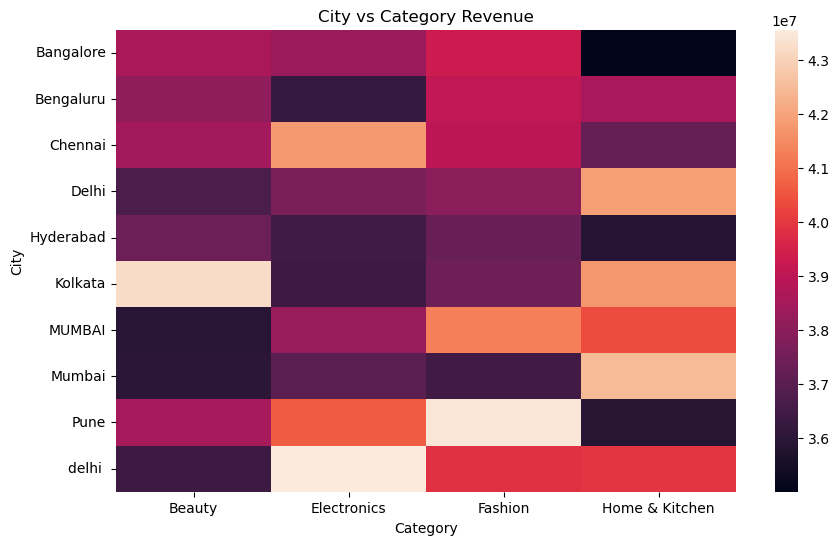

In [90]:
#City vs category pivot visualization
pivot_table = pd.pivot_table(
    df,
    values="revenue",
    index="city",
    columns="category",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=False)

plt.title("City vs Category Revenue")
plt.xlabel("Category")
plt.ylabel("City")
plt.show()

# Business Insight

In [92]:
#Top 5 actionable business insights (by revenue)
import pandas as pd

# Load CSV
df = pd.read_csv(r"C:\Users\dell\Downloads\retail_sales_50k_messy.csv")
df.columns = df.columns.str.strip().str.lower()  # clean column names

# Create 'sales' column
df['sales'] = df['quantity'] * df['final_unit_price']

# Top 5 categories by revenue
top5_categories = df.groupby('category').agg({
    'revenue':'sum',
    'sales':'sum'  # now exists
}).sort_values(by='revenue', ascending=False).head(5)

print("Top 5 Categories by Revenue:")
print(top5_categories)



Top 5 Categories by Revenue:
                     revenue         sales
category                                  
Fashion         4.001874e+08  4.001874e+08
Home & Kitchen  3.907163e+08  3.907163e+08
Beauty          3.886121e+08  3.886121e+08
Electronics     3.863405e+08  3.863405e+08


In [93]:
#Which city should receive more marketing budget
city_metrics = df.groupby('city').agg({
    'revenue':'sum',
    'sales':'sum'
})


city_metrics['revenue_per_sale'] = city_metrics['revenue'] / city_metrics['sales']

target_city = city_metrics.sort_values('revenue_per_sale').head(1)
print("City to Increase Marketing Budget:")
print(target_city)


City to Increase Marketing Budget:
                revenue         sales  revenue_per_sale
city                                                   
Bangalore  1.438229e+08  1.438229e+08               1.0


In [94]:
#Which category should the company expand
category_metrics = df.groupby('category').agg({
    'sales':'sum',
    'revenue':'sum'
})

expand_category = category_metrics.sort_values(['revenue','sales'], ascending=False).head(1)
print(" Category to Expand:")
print(expand_category)

 Category to Expand:
                 sales       revenue
category                            
Fashion   4.001874e+08  4.001874e+08


In [95]:
#Where is the biggest revenue leakage happening
df['revenue_loss'] = (df['discount_percent']/100) * (df['unit_price'] * df['quantity'])

leakage_by_category = df.groupby('category')['revenue_loss'].sum().sort_values(ascending=False).head(1)
print("Biggest Revenue Leakage Category:")
print(leakage_by_category)


Biggest Revenue Leakage Category:
category
Fashion    4.360155e+07
Name: revenue_loss, dtype: float64


In [96]:
#Should the company increase or reduce discounts
discount_analysis = df.groupby('discount_percent').agg({
    'sales':'sum',
    'revenue':'sum'
}).sort_values('revenue', ascending=False)

print(" Discount Analysis (Revenue vs Discount %):")
print(discount_analysis)

 Discount Analysis (Revenue vs Discount %):
                         sales       revenue
discount_percent                            
0.0               3.594567e+08  3.594567e+08
5.0               3.227670e+08  3.227670e+08
10.0              3.071512e+08  3.071512e+08
15.0              2.952990e+08  2.952990e+08
20.0              2.811824e+08  2.811824e+08


In [97]:
#Which sales channel should be prioritized
channel_metrics = df.groupby('sales_channel').agg({
    'sales':'sum',
    'revenue':'sum'
}).sort_values('revenue', ascending=False)

print("Sales Channel Prioritization:")
print(channel_metrics)

Sales Channel Prioritization:
                      sales       revenue
sales_channel                            
Online         7.873766e+08  7.873766e+08
In-Store       7.784797e+08  7.784797e+08


In [98]:
#Data quality improvements
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

print("Data Quality Check:")
print("Missing values per column:\n", missing_values)
print("Duplicate records:", duplicates)

Data Quality Check:
Missing values per column:
 order_id                0
order_date          12487
city                 4499
region              18306
category                0
product                 0
quantity             8171
unit_price            516
discount_percent     8426
final_unit_price    15258
revenue             15258
payment_method       9883
customer_type       16617
sales_channel           0
sales               15258
revenue_loss        15604
dtype: int64
Duplicate records: 0
